# Tissue DMR detection
Blood v. Brain plots for figure 1.

##### Modules

In [1]:
import pandas as pd
import numpy as np
import time
import psutil
import os
import re
from pybedtools import BedTool

import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib import font_manager
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors

from statsmodels.stats.multitest import multipletests
import scipy.stats as stats

##### Fonts & Colors

In [2]:
# font style
locations = ['/home/eger/software/fonts']
font_files = font_manager.findSystemFonts(fontpaths = locations)
for file in font_files:
    font_manager.fontManager.addfont(file)
plt.rcParams['font.family'] = 'Aptos'

# font size
b = 1
title_size = 18 + b
label_size = 16 + b
tick_size = 12 + b

color_dict = dict(zip(['unsmoothed', 'smoothed', 'modkit'], plt.cm.Dark2.colors[:3]))

##### Inputs

In [3]:
seg_cols = [
    'chrom',
    'start',
    'end',
    'state_name',
    'score',
    'n_sites',
    'a_counts',
    'b_counts',
    'a_mod_percentages',
    'b_mod_percentages',
    'a_frac_modified',
    'b_frac_modified',
    'effect_size',
    'cohen_h', 
    'cohen_h_low',
    'cohen_h_high'
]

In [4]:
REF_DIR = '/scratch/eger/projects/MethSmoothEval/tissues/ref_data'

DIR0 = '/scratch/eger/projects/MethSmoothEval/tissues/modkit/pileup'
DIR1 = '/scratch/eger/projects/MethSmoothEval/tissues/modkit/dmr'
DIR2 = '/scratch/eger/projects/MethSmoothEval/tissues/DSS'
OUTDIR = '/scratch/eger/projects/MethSmoothEval/tissues/DM_analysis'

## PPMI_3404_v_HBCC_81951_FTX
4kHz samples

In [5]:
sample1 = 'PPMI_3404'
sample2 = 'HBCC_81951_FTX'
pair = sample1+'_v_'+sample2
title = 'Blood2_4kHz v. Brain2_4kHz'

fname1 = os.path.join(DIR2, pair+'_DMLtest_DMRs.tsv')
fname2 = os.path.join(DIR2, pair+'_DMLtestwSmoothing_DMRs.tsv')

In [6]:
# read files
dss_unsmoothed_dmr_df = pd.read_csv(fname1, sep='\t').rename(columns={'chr': 'chrom'})
dss_smoothed_dmr_df = pd.read_csv(fname2, sep='\t').rename(columns={'chr': 'chrom'})

# add columns
dss_unsmoothed_dmr_df['name']=dss_unsmoothed_dmr_df['chrom'].astype(str)+":"+dss_unsmoothed_dmr_df['start'].astype(int).astype(str)+"-"+dss_unsmoothed_dmr_df['end'].astype(int).astype(str)
dss_smoothed_dmr_df['name']=dss_smoothed_dmr_df['chrom'].astype(str)+":"+dss_smoothed_dmr_df['start'].astype(int).astype(str)+"-"+dss_smoothed_dmr_df['end'].astype(int).astype(str)

dss_unsmoothed_dmr_df['type']='unsmoothed'
dss_smoothed_dmr_df['type']='smoothed'

dss_dmr_df = pd.concat([dss_unsmoothed_dmr_df, dss_smoothed_dmr_df], ignore_index=True)

In [17]:
dss_dmr_df['start'] = dss_dmr_df['start'].astype(int)
dss_dmr_df['end'] = dss_dmr_df['end'].astype(int)

### DMR length
Unsmoothed DMRs are shorter and there are less of them.

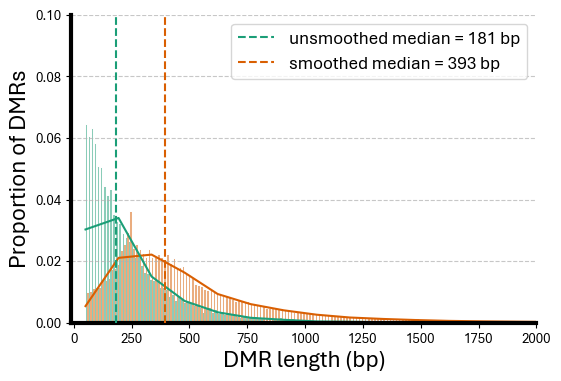

In [7]:
# initialize figure
fig, ax = plt.subplots(figsize=(6, 4))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

# plot per sample entropy distribution histogram with dodge set to true (side by side bars per data type)
ax = sb.histplot(data=dss_dmr_df,
                 x="length",
                 hue="type",
                 palette=color_dict,
                 multiple="dodge",
                 stat="proportion",
                 common_norm=False,
                 kde=True)

# median lines
for region_type in dss_dmr_df['type'].unique():
    median = dss_dmr_df[dss_dmr_df['type'] == region_type]['length'].median().astype(int)
    ax.axvline(median, color=color_dict[region_type], linestyle='--', 
           linewidth=1.5, zorder=4, 
           label=f'{region_type} median = {median} bp')

# set limits
ax.set_xlim(-10, 2000)
ax.set_ylim(0, 0.1)

# label x-axis
ax.set_xlabel("DMR length (bp)", fontsize=label_size)
# label y-axis
ax.set_ylabel("Proportion of DMRs", fontsize=label_size)

ax.legend(fontsize=tick_size)


plt.show()

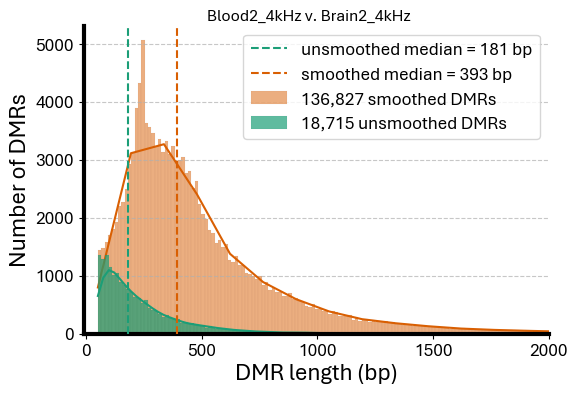

In [9]:
# initialize figure
fig, ax = plt.subplots(figsize=(6, 4))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

# --- plot smoothed FIRST (goes underneath) ---
n = dss_dmr_df[dss_dmr_df["type"] == "smoothed"].shape[0]
sb.histplot(
    data=dss_dmr_df[dss_dmr_df["type"] == "smoothed"],
    x="length",
    color=color_dict["smoothed"],
    stat="count",
    kde=True,
    element="bars",
    alpha=0.5,
    ax=ax,
    label=f"{n:,} smoothed DMRs",
    zorder=1
)

# --- plot unsmoothed SECOND (goes on top) ---
n = dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"].shape[0]
sb.histplot(
    data=dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"],
    x="length",
    color=color_dict["unsmoothed"],
    stat="count",
    kde=True,
    element="bars",
    alpha=0.7,
    ax=ax,
    label=f"{n:,} unsmoothed DMRs",
    zorder=2
)

# median lines
for region_type in dss_dmr_df['type'].unique():
    median = dss_dmr_df[dss_dmr_df['type'] == region_type]['length'].median().astype(int)
    ax.axvline(
        median,
        color=color_dict[region_type],
        linestyle='--',
        linewidth=1.5,
        zorder=4,
        label=f'{region_type} median = {median} bp'
    )

# limits and labels
ax.set_xlim(-10, 2000)
ax.tick_params(axis='both', labelsize=tick_size)
ax.set_xlabel("DMR length (bp)", fontsize=label_size)
ax.set_ylabel("Number of DMRs", fontsize=label_size)

# legend (now includes bars + medians)
ax.legend(fontsize=tick_size)

plt.suptitle(title, y=0.92)

plt.show()

### DMR effect size
Unsmoothed DMRs have larger effect sizes.

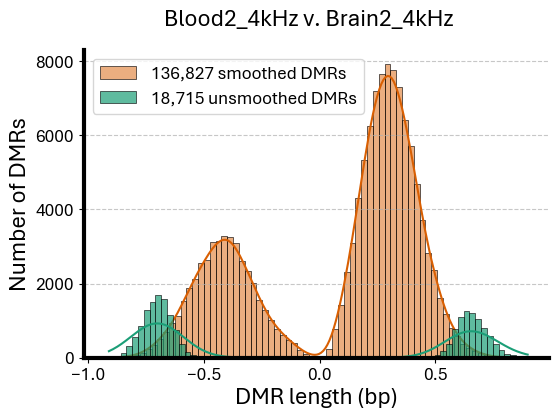

In [12]:
# initialize figure
fig, ax = plt.subplots(figsize=(6, 4))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

# --- plot smoothed FIRST (goes underneath) ---
n = dss_dmr_df[dss_dmr_df["type"] == "smoothed"].shape[0]
sb.histplot(
    data=dss_dmr_df[dss_dmr_df["type"] == "smoothed"],
    x="diff.Methy",
    color=color_dict["smoothed"],
    stat="count",
    binwidth=0.025,
    kde=True,
    element="bars",
    alpha=0.5,
    ax=ax,
    label=f"{n:,} smoothed DMRs",
    zorder=1
)

# --- plot unsmoothed SECOND (goes on top) ---
n = dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"].shape[0]
sb.histplot(
    data=dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"],
    x="diff.Methy",
    color=color_dict["unsmoothed"],
    stat="count",
    binwidth=0.025,
    kde=True,
    element="bars",
    alpha=0.7,
    ax=ax,
    label=f"{n:,} unsmoothed DMRs",
    zorder=2
)

# # median lines
# for region_type in dss_dmr_df['type'].unique():
#     median = dss_dmr_df[dss_dmr_df['type'] == region_type]['length'].median().astype(int)
#     ax.axvline(
#         median,
#         color=color_dict[region_type],
#         linestyle='--',
#         linewidth=1.5,
#         zorder=4,
#         label=f'{region_type} median = {median} bp'
#     )

# limits and labels
ax.tick_params(axis='both', labelsize=tick_size)
ax.set_xlabel("DMR length (bp)", fontsize=label_size)
ax.set_ylabel("Number of DMRs", fontsize=label_size)

# legend (now includes bars + medians)
ax.legend(fontsize=tick_size)

plt.suptitle(title, fontsize=label_size)

plt.show()

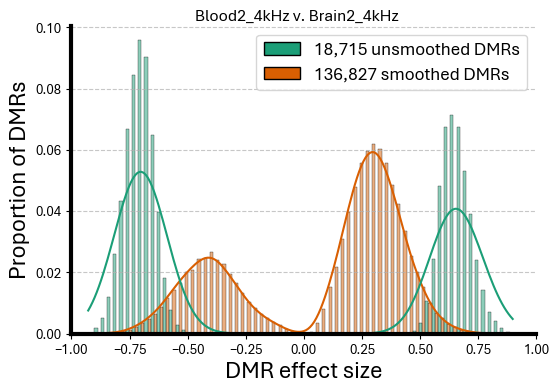

In [13]:
# initialize figure
fig, ax = plt.subplots(figsize=(6, 4))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

# plot per sample entropy distribution histogram with dodge set to true (side by side bars per data type)
ax = sb.histplot(data=dss_dmr_df,
                 x="diff.Methy",
                 hue="type",
                 palette=color_dict,
                 multiple="dodge",
                 stat="proportion",
                 common_norm=False,
                 kde=True)

# --- REMOVE seaborn legend ---
ax.legend_.remove()

n_unsmooth = dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"].shape[0]
n_smooth = dss_dmr_df[dss_dmr_df["type"] == "smoothed"].shape[0]

# --- CREATE custom legend ---
legend_handles = [
    Patch(facecolor=color_dict["unsmoothed"], edgecolor='black', 
          label=f"{n_unsmooth:,} unsmoothed DMRs"),
    Patch(facecolor=color_dict["smoothed"], edgecolor='black', 
          label=f"{n_smooth:,} smoothed DMRs")
]

ax.legend(handles=legend_handles, fontsize=tick_size, title="")

# set limits
ax.set_xlim(-1, 1)

# label x-axis
ax.set_xlabel("DMR effect size", fontsize=label_size)
# label y-axis
ax.set_ylabel("Proportion of DMRs", fontsize=label_size)

plt.suptitle(title, y=0.92)

plt.show()

### Reciprocal overlap between smoothed and unsmoothed DMRs
How often does one smoothed DMR covers multiple unsmoothed DMRs?

#### Calculate overlap occurrence

In [18]:
# split
smooth = dss_dmr_df[dss_dmr_df["type"] == "smoothed"].copy()
unsmooth = dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"].copy()

# make unique IDs
smooth["smooth_id"] = smooth.index #.astype(str)
unsmooth["unsmooth_id"] = unsmooth.index #.astype(str)

In [19]:
# BED-like dfs
smooth_bed_df = smooth[["chrom", "start", "end", "smooth_id"]]
unsmooth_bed_df = unsmooth[["chrom", "start", "end", "unsmooth_id"]]

smooth_bt = BedTool.from_dataframe(smooth_bed_df)
unsmooth_bt = BedTool.from_dataframe(unsmooth_bed_df)

# overlap smoothed DMRs with unsmoothed DMRs
# -wa -wb reports each pair
overlaps = smooth_bt.intersect(
    unsmooth_bt,
    wa=True,
    wb=True
).to_dataframe(
    names=[
        "chrom", "start", "end", "smooth_id",
        "u_chrom", "u_start", "u_end", "unsmooth_id"
    ]
)

In [20]:
# count how many unsmoothed segments each smoothed DMR overlaps
counts = (
    overlaps
    .groupby("smooth_id")["unsmooth_id"]
    .nunique()
    .rename("n_unsmoothed_segments")
    .reset_index()
)

# add zero-overlap smoothed DMRs back in
smooth_counts = (
    smooth[["chrom", "start", "end", "name", "smooth_id"]]
    .merge(counts, on="smooth_id", how="left")
)

smooth_counts["n_unsmoothed_segments"] = (
    smooth_counts["n_unsmoothed_segments"]
    .fillna(0)
    .astype(int)
)

In [21]:
# smoothed DMRs that cover multiple unsmoothed segments
multi_unsmoothed = smooth_counts[smooth_counts["n_unsmoothed_segments"] > 1]

# summary
n_smooth = len(smooth_counts)
n_multi = len(multi_unsmoothed)
frac_multi = n_multi / n_smooth

print(f"{n_multi:,} / {n_smooth:,} smoothed DMRs overlap >1 unsmoothed segment")
print(f"{frac_multi:.2%}")

# distribution
smooth_counts["n_unsmoothed_segments"].value_counts().sort_index()

1,791 / 136,827 smoothed DMRs overlap >1 unsmoothed segment
1.31%


n_unsmoothed_segments
0     120826
1      14210
2       1422
3        256
4         57
5         36
6          8
7          4
8          3
9          3
10         1
18         1
Name: count, dtype: int64

In [22]:
collapsed = pd.Series({
    "0": (smooth_counts["n_unsmoothed_segments"] == 0).sum(),
    "1": (smooth_counts["n_unsmoothed_segments"] == 1).sum(),
    "≥2": (smooth_counts["n_unsmoothed_segments"] >= 2).sum()
})

collapsed_pct = collapsed / collapsed.sum() * 100

#### Calculate boundary shift

In [23]:
matched = overlaps.copy()  # from earlier intersect

# keep only smoothed DMRs that overlap ≥1 unsmoothed
valid_smooth_ids = (
    matched["smooth_id"]
    .value_counts()
    .index
)

matched = matched[matched["smooth_id"].isin(valid_smooth_ids)]

In [24]:
# get smoothed coordinates
smooth_coords = smooth.set_index("smooth_id")[["start", "end"]]

# aggregate unsmoothed spans per smoothed DMR
unsmooth_agg = (
    overlaps
    .groupby("smooth_id")
    .agg(
        u_start=("u_start", "min"),
        u_end=("u_end", "max")
    )
)

loci = smooth_coords.join(unsmooth_agg, how="inner")

In [25]:
loci["left_shift"] = loci["start"] - loci["u_start"]
loci["right_shift"] = loci["end"] - loci["u_end"]

In [26]:
loci["length_smooth"] = loci["end"] - loci["start"]
loci["length_unsmooth"] = loci["u_end"] - loci["u_start"]

loci["length_diff"] = loci["length_smooth"] - loci["length_unsmooth"]
loci["length_ratio"] = loci["length_smooth"] / loci["length_unsmooth"]

In [158]:
# compare effect sizes
unsmooth_effect = (
    overlaps
    .merge(unsmooth[["unsmooth_id", "diff.Methy"]], on="unsmooth_id")
    .groupby("smooth_id")["diff.Methy"]
    .mean()
    .rename("unsmooth_mean_diff")
)

smooth_effect = smooth.set_index("smooth_id")["diff.Methy"]

loci = loci.join(smooth_effect).join(unsmooth_effect)

loci["effect_diff"] = loci["diff.Methy"] - loci["unsmooth_mean_diff"]

#### Plot overlap occurrence

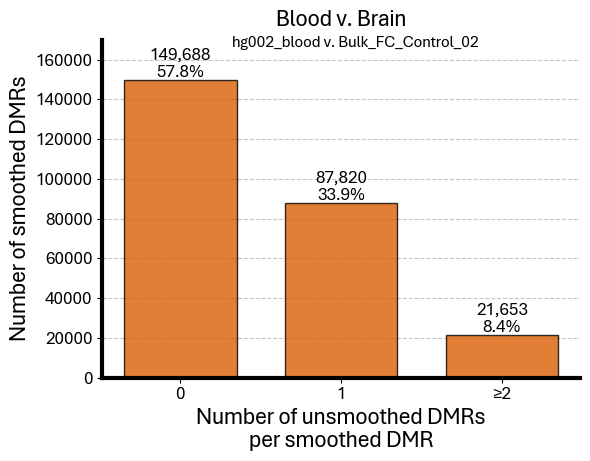

In [163]:
# initialize figure
fig, ax = plt.subplots(figsize=(6, 5))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

bars = ax.bar(collapsed.index, 
              collapsed.values,
              width=0.7,
             color=color_dict['smoothed'],
              edgecolor='black',
              alpha=0.8,
             zorder=2)

for i, bar in enumerate(bars):
    count = collapsed.iloc[i]
    pct = collapsed_pct.iloc[i]
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=tick_size
    )

ax.set_ylim(0, 170000)

ax.tick_params(axis='both', labelsize=tick_size)
ax.set_xlabel("Number of unsmoothed DMRs\nper smoothed DMR", fontsize=label_size)
ax.set_ylabel("Number of smoothed DMRs", fontsize=label_size)

ax.set_title('Blood v. Brain', fontsize=label_size, pad=10)
plt.suptitle(title, x=0.6, y=0.86)

plt.tight_layout()
plt.show()

#### Plot boundary shift and effect size changes

In [194]:
plot_df = loci.dropna(
    subset=["length_unsmooth", "length_smooth", "effect_diff"]
).copy()

# optional: use absolute effect size difference instead
plot_df["effect_diff_plot"] = plot_df["effect_diff"].abs()

In [195]:
plot_df["effect_diff_plot"].describe()

count    1.094730e+05
mean     8.392059e-02
std      7.825251e-02
min      4.493967e-07
25%      2.268458e-02
50%      6.285558e-02
75%      1.224825e-01
max      1.038457e+00
Name: effect_diff_plot, dtype: float64

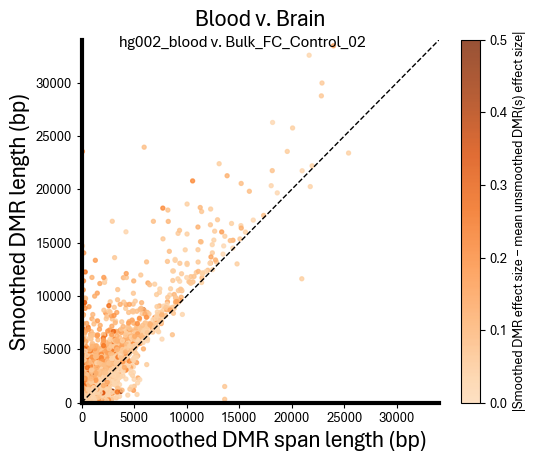

In [197]:
fig, ax = plt.subplots(figsize=(5.5, 5))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)

# truncate colormap to remove the lightest ~20%
orig_cmap = plt.cm.Oranges
trunc_cmap = mcolors.LinearSegmentedColormap.from_list(
    "trunc_oranges",
    orig_cmap(np.linspace(0.2, 1, 256))
)

sc = ax.scatter(
    plot_df["length_unsmooth"],
    plot_df["length_smooth"],
    c=plot_df["effect_diff_plot"],
    cmap=trunc_cmap,
    s=8,
    alpha=0.8,
    vmin=0,
    vmax=0.5
)

# y = x diagonal
max_len = max(
    plot_df["length_unsmooth"].max(),
    plot_df["length_smooth"].max()
)

ax.plot(
    [0, max_len],
    [0, max_len],
    linestyle="--",
    linewidth=1,
    color='black',
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("|Smoothed DMR effect size − mean unsmoothed DMR(s) effect size|")

ax.set_xlabel("Unsmoothed DMR span length (bp)", fontsize=label_size)
ax.set_ylabel("Smoothed DMR length (bp)", fontsize=label_size)

ax.set_xlim(0, 34000)
ax.set_ylim(0, 34000)

ax.set_title('Blood v. Brain', fontsize=label_size, pad=10)
plt.suptitle(title, x=0.45, y=0.86)

plt.tight_layout()
plt.show()